In [12]:
import pandas as pd

df = pd.read_csv('/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# ABC Communications - Customer Churn Analysis
## Week 1 Business Analytics Case Study

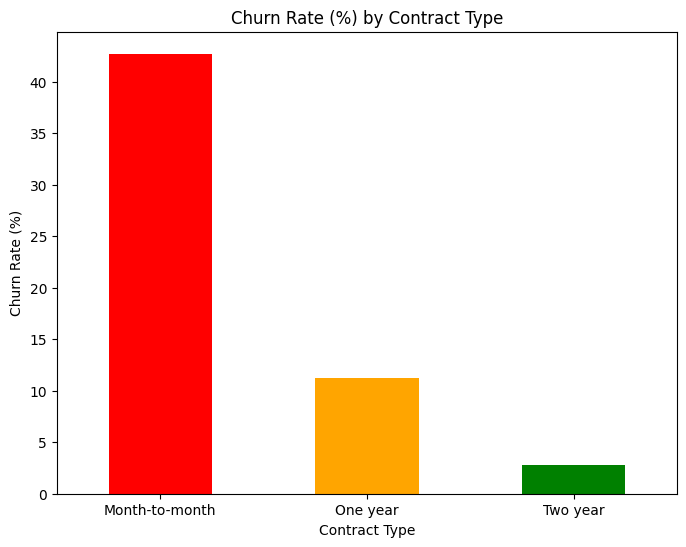

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

churn_contract = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()*100)

plt.figure(figsize=(8,6))
churn_contract.plot(kind='bar', color=['red','orange','green'])
plt.title('Churn Rate (%) by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

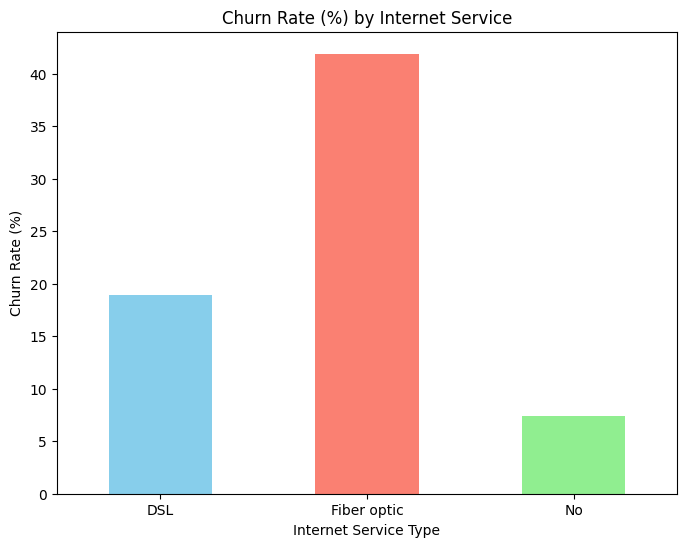

In [14]:
churn_internet = df.groupby('InternetService')['Churn'].apply(lambda x: (x=='Yes').mean()*100)

plt.figure(figsize=(8,6))
churn_internet.plot(kind='bar', color=['skyblue','salmon','lightgreen'])
plt.title('Churn Rate (%) by Internet Service')
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

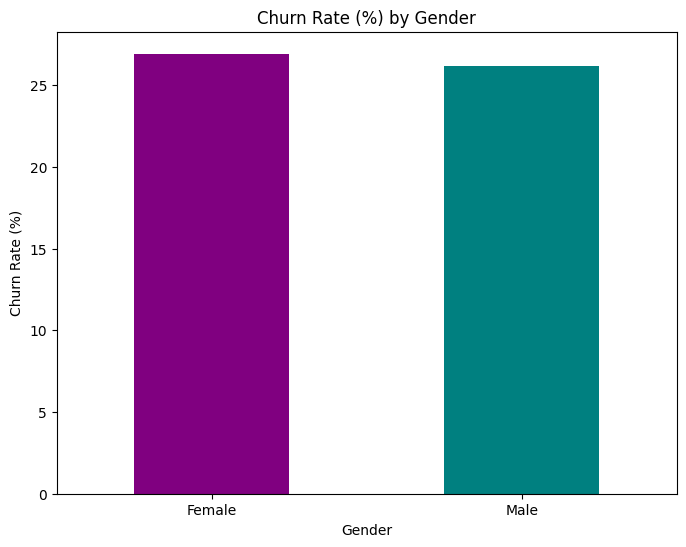

In [15]:
churn_gender = df.groupby('gender')['Churn'].apply(lambda x: (x=='Yes').mean()*100)

plt.figure(figsize=(8,6))
churn_gender.plot(kind='bar', color=['purple','teal'])
plt.title('Churn Rate (%) by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

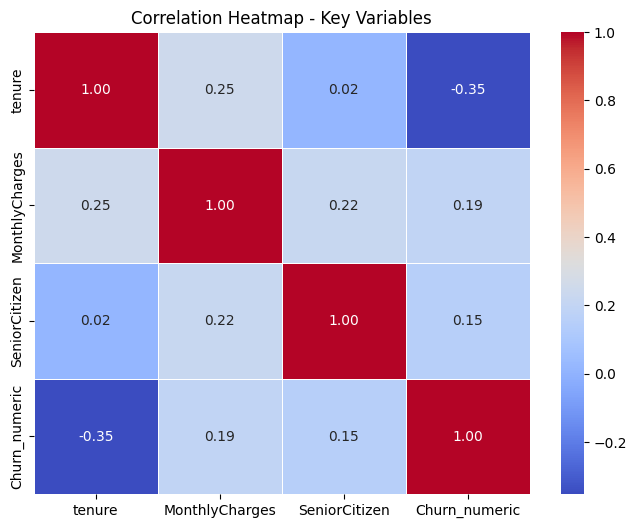

In [17]:
# Convert Churn to numbers (Yes=1, No=0) so we can include it in correlation
df['Churn_numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Select the numeric columns we want to compare
numeric_cols = df[['tenure', 'MonthlyCharges', 'SeniorCitizen', 'Churn_numeric']]

# Calculate correlation
correlation = numeric_cols.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap - Key Variables')
plt.show()

## Key Insight: Contract Type Drives Churn

Month-to-month customers churn significantly more than customers on
1-year or 2-year contracts. This suggests that contract commitment
is one of the strongest predictors of customer loyalty.

**Recommendation:** ABC Communications should incentivize customers
to upgrade from month-to-month to annual contracts through discounts
or bonus offers.